In [6]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [29]:
from pathlib import Path

BASE_DIR = Path.cwd()
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = BASE_DIR / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR.resolve())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())
print("DATA_DIR:", DATA_DIR.resolve())

BASE_DIR: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09
ARTIFACTS_DIR: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts
FIGURES_DIR: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\figures
DATA_DIR: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\data


In [30]:
BATCH_SIZE = 128
VAL_RATIO = 0.2

transform = transforms.ToTensor()

full_train_dataset = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=False,
    transform=transform,
    download=True,
)

NUM_CLASSES = len(full_train_dataset.classes)
print("Number of classes:", NUM_CLASSES)

train_size = int((1 - VAL_RATIO) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

100.0%


Number of classes: 47
Train size: 90240
Val size: 22560
Test size: 18800


In [31]:
x_batch, y_batch = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("x min:", x_batch.min().item())
print("x max:", x_batch.max().item())
print("labels min:", y_batch.min().item())
print("labels max:", y_batch.max().item())
print("unique labels in batch:", torch.unique(y_batch).tolist()[:20])

x_batch shape: torch.Size([128, 1, 28, 28])
y_batch shape: torch.Size([128])
x dtype: torch.float32
y dtype: torch.int64
x min: 0.0
x max: 1.0
labels min: 0
labels max: 46
unique labels in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20]


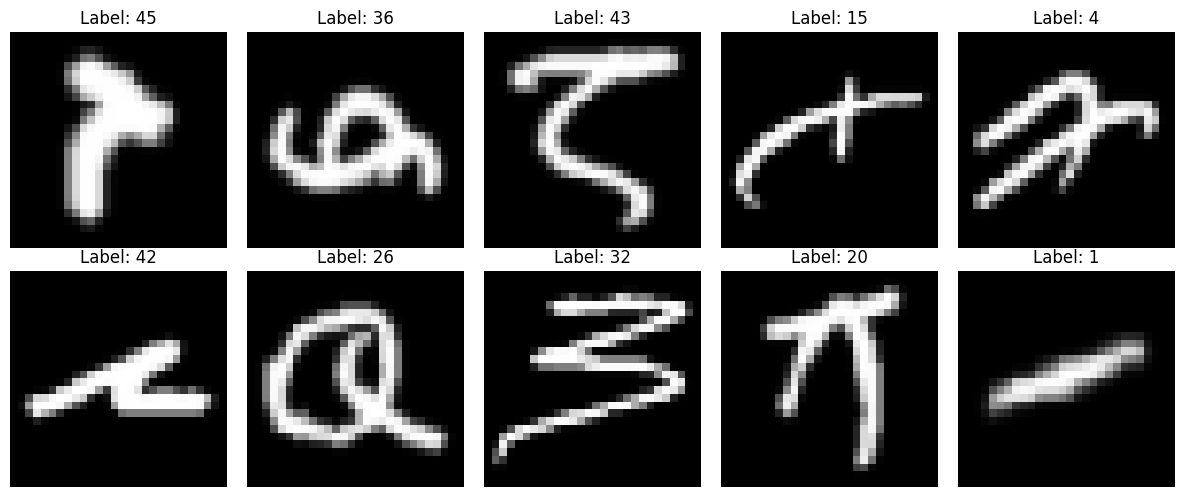

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img, label = full_train_dataset[i]
    axes[i].imshow(img.squeeze(0), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [33]:
class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim=28 * 28,
        num_classes=47,
        hidden_sizes=(512, 256, 128),
        activation_name="relu",
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        if activation_name == "relu":
            activation_cls = nn.ReLU
        elif activation_name == "gelu":
            activation_cls = nn.GELU
        else:
            raise ValueError(f"Unsupported activation: {activation_name}")

        layers = [nn.Flatten()]
        prev_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [34]:
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [35]:
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop

In [36]:
def build_optimizer(model, optimizer_name, lr, weight_decay=0.0, momentum=0.0):
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def run_experiment(
    experiment_id,
    model_config,
    train_loader,
    val_loader,
    device,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    use_early_stopping=False,
    patience=4,
):
    model = MLPClassifier(**model_config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(
        model,
        optimizer_name=optimizer_name,
        lr=lr,
        weight_decay=weight_decay,
        momentum=momentum,
    )

    stopper = EarlyStopping(patience=patience) if use_early_stopping else None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state_dict = None
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

        print(
            f"{experiment_id} | epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if stopper is not None:
            if stopper.step(val_loss):
                print(f"Early stopping triggered at epoch {epoch}")
                break

    result = {
        "experiment_id": experiment_id,
        "dataset": "EMNIST",
        "seed": SEED,
        "model_summary": (
            f"hidden={model_config['hidden_sizes']}; "
            f"act={model_config['activation_name']}; "
            f"dropout={model_config['dropout']}; "
            f"batchnorm={model_config['use_batchnorm']}"
        ),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

    return {
        "model": model,
        "history": history,
        "result": result,
        "best_state_dict": best_state_dict,
        "model_config": model_config,
    }

In [37]:
base_model_config = {
    "input_dim": 28 * 28,
    "num_classes": NUM_CLASSES,
    "hidden_sizes": (512, 256, 128),
    "activation_name": "relu",
    "dropout": 0.0,
    "use_batchnorm": False,
}

experiments_A = {
    "E1": {
        "model_config": {
            **base_model_config,
            "dropout": 0.0,
            "use_batchnorm": False,
        },
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs": 15,
        "use_early_stopping": False,
        "patience": 4,
    },
    "E2": {
        "model_config": {
            **base_model_config,
            "dropout": 0.3,
            "use_batchnorm": False,
        },
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs": 15,
        "use_early_stopping": False,
        "patience": 4,
    },
    "E3": {
        "model_config": {
            **base_model_config,
            "dropout": 0.0,
            "use_batchnorm": True,
        },
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs": 15,
        "use_early_stopping": False,
        "patience": 4,
    },
}

In [16]:
all_results = []
all_histories = {}
all_runs = {}

for exp_id, cfg in experiments_A.items():
    output = run_experiment(
        experiment_id=exp_id,
        model_config=cfg["model_config"],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        optimizer_name=cfg["optimizer_name"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        weight_decay=cfg["weight_decay"],
        epochs=cfg["epochs"],
        use_early_stopping=cfg["use_early_stopping"],
        patience=cfg["patience"],
    )
    all_results.append(output["result"])
    all_histories[exp_id] = output["history"]
    all_runs[exp_id] = output

results_A_df = pd.DataFrame(all_results)
results_A_df.sort_values("best_val_accuracy", ascending=False)

E1 | epoch 01/15 | train_loss=1.1627 train_acc=0.6570 | val_loss=0.6973 val_acc=0.7805
E1 | epoch 02/15 | train_loss=0.6102 train_acc=0.8001 | val_loss=0.5826 val_acc=0.8097
E1 | epoch 03/15 | train_loss=0.4999 train_acc=0.8295 | val_loss=0.5489 val_acc=0.8195
E1 | epoch 04/15 | train_loss=0.4380 train_acc=0.8465 | val_loss=0.4937 val_acc=0.8346
E1 | epoch 05/15 | train_loss=0.3945 train_acc=0.8596 | val_loss=0.4734 val_acc=0.8426
E1 | epoch 06/15 | train_loss=0.3577 train_acc=0.8702 | val_loss=0.4844 val_acc=0.8418
E1 | epoch 07/15 | train_loss=0.3280 train_acc=0.8774 | val_loss=0.4903 val_acc=0.8307
E1 | epoch 08/15 | train_loss=0.3055 train_acc=0.8841 | val_loss=0.4918 val_acc=0.8429
E1 | epoch 09/15 | train_loss=0.2827 train_acc=0.8915 | val_loss=0.4725 val_acc=0.8505
E1 | epoch 10/15 | train_loss=0.2648 train_acc=0.8977 | val_loss=0.4962 val_acc=0.8464
E1 | epoch 11/15 | train_loss=0.2490 train_acc=0.9011 | val_loss=0.5314 val_acc=0.8391
E1 | epoch 12/15 | train_loss=0.2315 train_

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
2,E3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.001,0.0,0.0,15,0.856206,0.484334,14
1,E2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.3;...",Adam,0.001,0.0,0.0,15,0.853236,0.432807,15
0,E1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.001,0.0,0.0,15,0.850532,0.472511,9


In [17]:
candidate_ids = ["E2", "E3"]
best_candidate_id = max(candidate_ids, key=lambda x: all_runs[x]["result"]["best_val_accuracy"])
best_candidate_cfg = experiments_A[best_candidate_id]

print("Best candidate for E4:", best_candidate_id)

output_E4 = run_experiment(
    experiment_id="E4",
    model_config=best_candidate_cfg["model_config"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name=best_candidate_cfg["optimizer_name"],
    lr=best_candidate_cfg["lr"],
    momentum=best_candidate_cfg["momentum"],
    weight_decay=best_candidate_cfg["weight_decay"],
    epochs=20,
    use_early_stopping=True,
    patience=4,
)

all_results.append(output_E4["result"])
all_histories["E4"] = output_E4["history"]
all_runs["E4"] = output_E4

pd.DataFrame(all_results).sort_values("best_val_accuracy", ascending=False)

Best candidate for E4: E3
E4 | epoch 01/20 | train_loss=0.8951 train_acc=0.7486 | val_loss=0.5625 val_acc=0.8184
E4 | epoch 02/20 | train_loss=0.4916 train_acc=0.8331 | val_loss=0.4691 val_acc=0.8439
E4 | epoch 03/20 | train_loss=0.4138 train_acc=0.8544 | val_loss=0.4513 val_acc=0.8488
E4 | epoch 04/20 | train_loss=0.3656 train_acc=0.8672 | val_loss=0.4426 val_acc=0.8531
E4 | epoch 05/20 | train_loss=0.3293 train_acc=0.8778 | val_loss=0.4350 val_acc=0.8507
E4 | epoch 06/20 | train_loss=0.3032 train_acc=0.8853 | val_loss=0.4352 val_acc=0.8552
E4 | epoch 07/20 | train_loss=0.2816 train_acc=0.8912 | val_loss=0.4434 val_acc=0.8509
E4 | epoch 08/20 | train_loss=0.2609 train_acc=0.8984 | val_loss=0.4311 val_acc=0.8541
E4 | epoch 09/20 | train_loss=0.2447 train_acc=0.9038 | val_loss=0.4531 val_acc=0.8497
E4 | epoch 10/20 | train_loss=0.2315 train_acc=0.9081 | val_loss=0.4555 val_acc=0.8549
E4 | epoch 11/20 | train_loss=0.2180 train_acc=0.9114 | val_loss=0.4618 val_acc=0.8531
E4 | epoch 12/20 

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
2,E3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.001,0.0,0.0,15,0.856206,0.484334,14
3,E4,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.001,0.0,0.0,12,0.855186,0.435234,6
1,E2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.3;...",Adam,0.001,0.0,0.0,15,0.853236,0.432807,15
0,E1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.001,0.0,0.0,15,0.850532,0.472511,9


In [18]:
best_model = MLPClassifier(**output_E4["model_config"]).to(device)
best_model.load_state_dict(output_E4["best_state_dict"])

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

print(f"Final TEST loss: {test_loss:.4f}")
print(f"Final TEST accuracy: {test_acc:.4f}")

Final TEST loss: 0.4594
Final TEST accuracy: 0.8473


In [20]:
best_arch_config = output_E4["model_config"]

experiments_B = {
    "O1": {
        "model_config": best_arch_config,
        "optimizer_name": "Adam",
        "lr": 1e-1,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs": 6,
        "use_early_stopping": False,
        "patience": 4,
    },
    "O2": {
        "model_config": best_arch_config,
        "optimizer_name": "Adam",
        "lr": 1e-5,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs": 6,
        "use_early_stopping": False,
        "patience": 4,
    },
    "O3": {
        "model_config": best_arch_config,
        "optimizer_name": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs": 12,
        "use_early_stopping": False,
        "patience": 4,
    },
}

In [21]:
for exp_id, cfg in experiments_B.items():
    output = run_experiment(
        experiment_id=exp_id,
        model_config=cfg["model_config"],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        optimizer_name=cfg["optimizer_name"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        weight_decay=cfg["weight_decay"],
        epochs=cfg["epochs"],
        use_early_stopping=cfg["use_early_stopping"],
        patience=cfg["patience"],
    )
    all_results.append(output["result"])
    all_histories[exp_id] = output["history"]
    all_runs[exp_id] = output

runs_df = pd.DataFrame(all_results)
runs_df.sort_values("experiment_id")

O1 | epoch 01/6 | train_loss=1.0874 train_acc=0.6682 | val_loss=0.7476 val_acc=0.7619
O1 | epoch 02/6 | train_loss=0.7410 train_acc=0.7610 | val_loss=0.6712 val_acc=0.7849
O1 | epoch 03/6 | train_loss=0.6534 train_acc=0.7859 | val_loss=0.5913 val_acc=0.8111
O1 | epoch 04/6 | train_loss=0.6116 train_acc=0.7976 | val_loss=0.6613 val_acc=0.7847
O1 | epoch 05/6 | train_loss=0.5658 train_acc=0.8088 | val_loss=0.6194 val_acc=0.8040
O1 | epoch 06/6 | train_loss=0.5351 train_acc=0.8191 | val_loss=0.5677 val_acc=0.8208
O2 | epoch 01/6 | train_loss=3.3397 train_acc=0.2696 | val_loss=2.9393 val_acc=0.4426
O2 | epoch 02/6 | train_loss=2.7180 train_acc=0.5053 | val_loss=2.5008 val_acc=0.5535
O2 | epoch 03/6 | train_loss=2.3520 train_acc=0.5811 | val_loss=2.1886 val_acc=0.6097
O2 | epoch 04/6 | train_loss=2.0726 train_acc=0.6314 | val_loss=1.9412 val_acc=0.6519
O2 | epoch 05/6 | train_loss=1.8448 train_acc=0.6679 | val_loss=1.7305 val_acc=0.6804
O2 | epoch 06/6 | train_loss=1.6521 train_acc=0.6948 |

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
0,E1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.850532,0.472511,9
1,E2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.3;...",Adam,0.00100,0.0,0.0000,15,0.853236,0.432807,15
2,E3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.856206,0.484334,14
3,E4,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,12,0.855186,0.435234,6
4,O1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.10000,0.0,0.0000,6,0.820789,0.567671,6
5,O2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00001,0.0,0.0000,6,0.703812,1.558545,6
6,O3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",SGD,0.01000,0.9,0.0001,12,0.852881,0.453676,12


In [38]:
runs_df = runs_df[
    [
        "experiment_id",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "momentum",
        "weight_decay",
        "epochs_trained",
        "best_val_accuracy",
        "best_val_loss",
    ]
].sort_values("experiment_id")

runs_csv_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_csv_path, index=False)

print("Saved:", runs_csv_path.resolve())
runs_df

Saved: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.850532,0.472511
1,E2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.3;...",Adam,0.00100,0.0,0.0000,15,0.853236,0.432807
2,E3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.856206,0.484334
3,E4,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00100,0.0,0.0000,12,0.855186,0.435234
4,O1,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.10000,0.0,0.0000,6,0.820789,0.567671
5,O2,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",Adam,0.00001,0.0,0.0000,6,0.703812,1.558545
6,O3,EMNIST,42,"hidden=(512, 256, 128); act=relu; dropout=0.0;...",SGD,0.01000,0.9,0.0001,12,0.852881,0.453676


In [39]:
best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(output_E4["best_state_dict"], best_model_path)

print("Saved:", best_model_path.resolve())

Saved: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\best_model.pt


In [43]:
best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": SEED,
    "model_config": output_E4["model_config"],
    "optimizer": best_candidate_cfg["optimizer_name"],
    "lr": best_candidate_cfg["lr"],
    "momentum": best_candidate_cfg["momentum"],
    "weight_decay": best_candidate_cfg["weight_decay"],
    "early_stopping_patience": 4,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
}

best_config_path = ARTIFACTS_DIR / "best_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("Saved:", best_config_path.resolve())

Saved: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\best_config.json


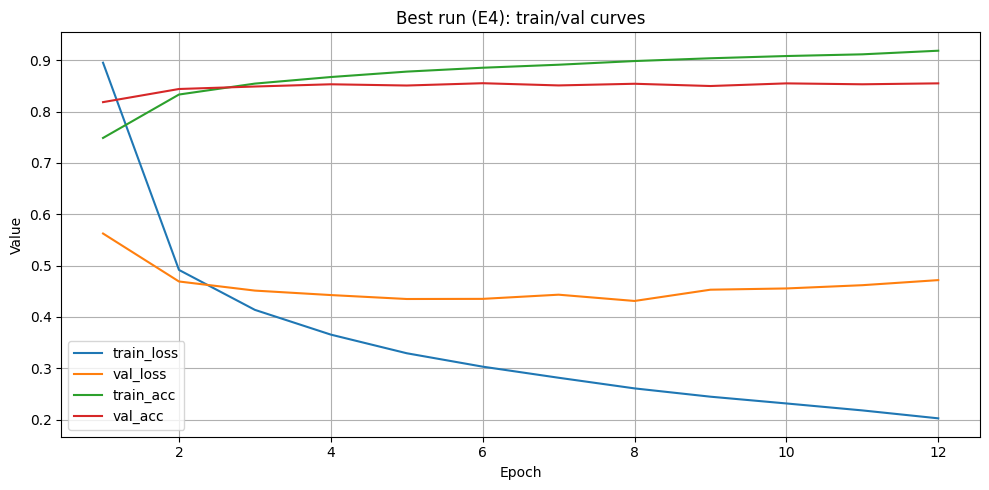

Saved: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\figures\curves_best.png


In [41]:
history_E4 = all_histories["E4"]

epochs_e4 = range(1, len(history_E4["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_e4, history_E4["train_loss"], label="train_loss")
plt.plot(epochs_e4, history_E4["val_loss"], label="val_loss")
plt.plot(epochs_e4, history_E4["train_acc"], label="train_acc")
plt.plot(epochs_e4, history_E4["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Best run (E4): train/val curves")
plt.legend()
plt.grid(True)
plt.tight_layout()

curves_best_path = FIGURES_DIR / "curves_best.png"
plt.savefig(curves_best_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", curves_best_path.resolve())

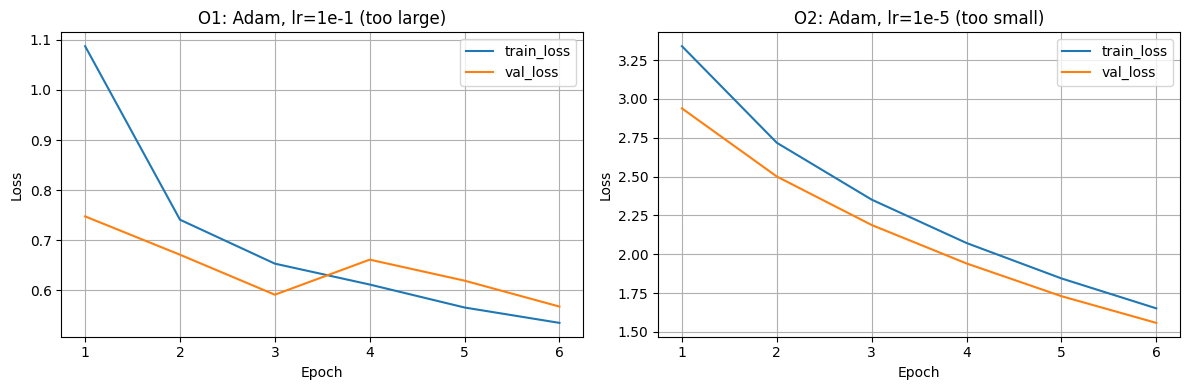

Saved: C:\Users\sveti\PycharmProjects\DPO_II\aie-group\homeworks\HW08-09\artifacts\figures\curves_lr_extremes.png


In [44]:
history_O1 = all_histories["O1"]
history_O2 = all_histories["O2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_o1 = range(1, len(history_O1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_O2["train_loss"]) + 1)

axes[0].plot(epochs_o1, history_O1["train_loss"], label="train_loss")
axes[0].plot(epochs_o1, history_O1["val_loss"], label="val_loss")
axes[0].set_title("O1: Adam, lr=1e-1 (too large)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_o2, history_O2["train_loss"], label="train_loss")
axes[1].plot(epochs_o2, history_O2["val_loss"], label="val_loss")
axes[1].set_title("O2: Adam, lr=1e-5 (too small)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

curves_lr_path = FIGURES_DIR / "curves_lr_extremes.png"
plt.savefig(curves_lr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", curves_lr_path.resolve())

In [45]:
print("=== Final summary ===")
print(runs_df.to_string(index=False))
print()
print("Best homework model: E4")
print(f"Best candidate before early stopping: {best_candidate_id}")
print(f"Final TEST loss: {test_loss:.4f}")
print(f"Final TEST accuracy: {test_acc:.4f}")

=== Final summary ===
experiment_id dataset  seed                                                  model_summary optimizer      lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1  EMNIST    42 hidden=(512, 256, 128); act=relu; dropout=0.0; batchnorm=False      Adam 0.00100       0.0        0.0000              15           0.850532       0.472511
           E2  EMNIST    42 hidden=(512, 256, 128); act=relu; dropout=0.3; batchnorm=False      Adam 0.00100       0.0        0.0000              15           0.853236       0.432807
           E3  EMNIST    42  hidden=(512, 256, 128); act=relu; dropout=0.0; batchnorm=True      Adam 0.00100       0.0        0.0000              15           0.856206       0.484334
           E4  EMNIST    42  hidden=(512, 256, 128); act=relu; dropout=0.0; batchnorm=True      Adam 0.00100       0.0        0.0000              12           0.855186       0.435234
           O1  EMNIST    42  hidden=(512, 256, 128); act=relu; 